In [11]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:.4f}'.format)

In [12]:
MODEL_PATH    = r'..\models\best_model.pkl'
FEATURES_PATH = r'..\models\model_columns.pkl'
Data_path=r'..\data\amex_selected_features.parquet'

best_model=joblib.load(MODEL_PATH)
model_cols=joblib.load(FEATURES_PATH)

df=pd.read_parquet(Data_path)

print(f'Model:Logistic Regression-Class weights')
print(f'Data shape:{df.shape}')
print(f'Model expects {len(model_cols)} features')

Model:Logistic Regression-Class weights
Data shape:(458913, 130)
Model expects 129 features


In [13]:
ENCODERS_PATH = r'..\models\label_encoders.pkl'
label_encoders=joblib.load(ENCODERS_PATH)

cat_cols=[col for col in label_encoders.keys() if col in df.columns]

for col in cat_cols:
    df[col]=label_encoders[col].transform(df[col].astype(str))
    
print(f'Encoded {len(cat_cols)} categorical columns')

Encoded 8 categorical columns


In [14]:
X=df[model_cols]

log_odds=best_model.decision_function(X)

print(f'Log-odds calc for {len(log_odds):,} customers')

print(f'log odds range:{log_odds.min():.4f} to {log_odds.max():.4f}')

print(f'Log-odds mean: {log_odds.mean():.4f}')


Log-odds calc for 458,913 customers
log odds range:-65.0434 to 53.3373
Log-odds mean: -1.2801


In [15]:
PDO=20
Base_score=600
base_odds=(df['target']==0).sum()/(df['target']==1).sum()

factor=PDO/np.log(2)
offset=Base_score-factor*np.log(base_odds)

print(f'Population good odds (non-default:default): {base_odds:.4f}')
print(f'Factor: {factor:.4f}')
print(f'Offset: {offset:.4f}')
print()
print(f'PDO = {PDO} → every {PDO} points doubles or halves default odds')
print(f'Base Score = {Base_score} → average risk customer scores {Base_score}')

Population good odds (non-default:default): 2.8620
Factor: 28.8539
Offset: 569.6596

PDO = 20 → every 20 points doubles or halves default odds
Base Score = 600 → average risk customer scores 600


In [16]:
log_odds = best_model.decision_function(X)

# negate — decision_function outputs log-odds of default (class 1)
# we want log-odds of being good (class 0) for scorecard direction
# higher score = lower risk
log_odds_good = -log_odds
df['score'] = (offset + factor * log_odds_good).round().astype(int)

# clip to 300-850 range
df['score'] = df['score'].clip(lower=300, upper=850)

print(f'Score range after clipping: {df["score"].min()} to {df["score"].max()}')
print(f'Score mean: {df["score"].mean():.2f}')
print(f'Score std: {df["score"].std():.2f}')
print()
print('Score distribution by percentile:')
print(df['score'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))

Score range after clipping: 300 to 850
Score mean: 606.86
Score std: 97.11

Score distribution by percentile:
count   458913.0000
mean       606.8622
std         97.1133
min        300.0000
5%         426.0000
25%        540.0000
50%        631.0000
75%        684.0000
95%        727.0000
max        850.0000
Name: score, dtype: float64


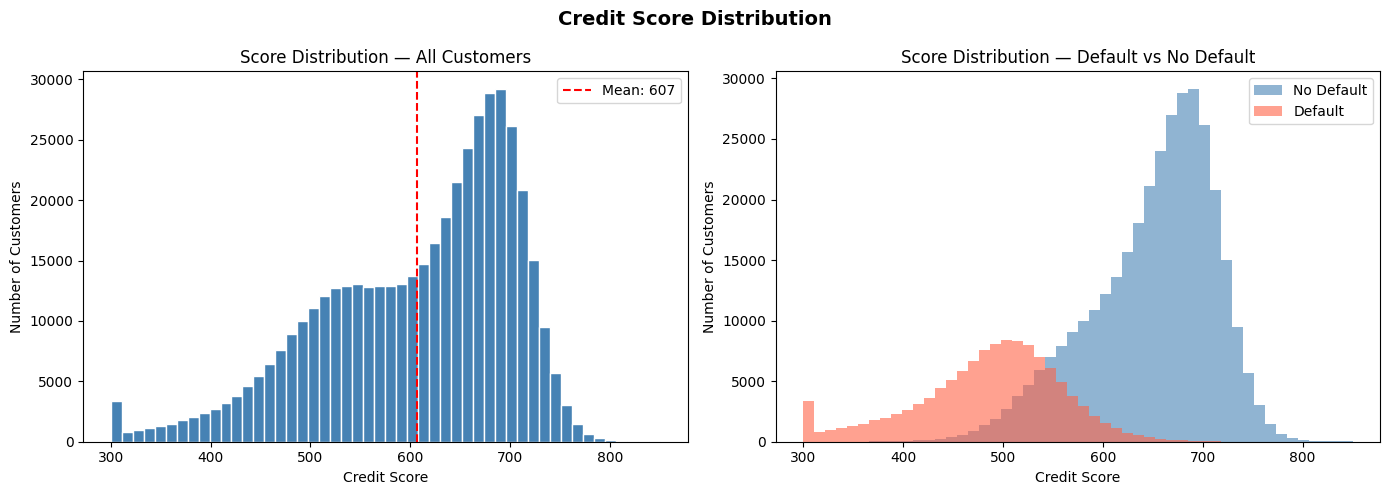

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# overall score distribution
axes[0].hist(df['score'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Score Distribution — All Customers')
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Number of Customers')
axes[0].axvline(x=df['score'].mean(), color='red', linestyle='--', label=f'Mean: {df["score"].mean():.0f}')
axes[0].legend()

# score distribution by target
axes[1].hist(df[df['target']==0]['score'], bins=50, alpha=0.6, color='steelblue', label='No Default')
axes[1].hist(df[df['target']==1]['score'], bins=50, alpha=0.6, color='tomato', label='Default')
axes[1].set_title('Score Distribution — Default vs No Default')
axes[1].set_xlabel('Credit Score')
axes[1].set_ylabel('Number of Customers')
axes[1].legend()

plt.suptitle('Credit Score Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# calculate percentile-based thresholds from actual score distribution
p20 = int(df['score'].quantile(0.20))
p40 = int(df['score'].quantile(0.40))
p60 = int(df['score'].quantile(0.60))
p80 = int(df['score'].quantile(0.80))

print(f'Thresholds: Poor<{p20}, Fair {p20}-{p40}, Good {p40}-{p60}, Very Good {p60}-{p80}, Exceptional>{p80}')

def assign_risk_band(score):
    if score >= p80:
        return 'Exceptional'
    elif score >= p60:
        return 'Very Good'
    elif score >= p40:
        return 'Good'
    elif score >= p20:
        return 'Fair'
    else:
        return 'Poor'

df['risk_band'] = df['score'].apply(assign_risk_band)

risk_summary = df.groupby('risk_band').agg(
    customer_count=('score', 'count'),
    avg_score=('score', 'mean'),
    default_rate=('target', 'mean')
).round(4)

band_order = ['Poor', 'Fair', 'Good', 'Very Good', 'Exceptional']
risk_summary = risk_summary.reindex(band_order)

print()
print('Risk Band Summary:')
print(risk_summary.to_string())

Thresholds: Poor<520, Fair 520-598, Good 598-656, Very Good 656-692, Exceptional>692

Risk Band Summary:
             customer_count  avg_score  default_rate
risk_band                                           
Poor                  91130   453.8373        0.8653
Fair                  91597   558.6066        0.3834
Good                  92219   629.4638        0.0461
Very Good             90567   674.1252        0.0051
Exceptional           93400   715.9537        0.0015


In [21]:
coefficients=pd.DataFrame({
    'feature':model_cols,
    'coefficient':best_model.coef_[0]
})

coefficients['score_contribution']=coefficients['coefficient']*factor

coefficients['abs_contribution']=coefficients['score_contribution'].abs()
coefficients=coefficients.sort_values('abs_contribution',ascending=False).reset_index(drop=True)

print('Top 20 features by score contribution:')
print(coefficients.head(20)[['feature','coefficient','score_contribution']].to_string(index=False))

scorecard_path=r'..\outputs\scorecard_table.csv'
coefficients.to_csv(scorecard_path,index=False)


Top 20 features by score contribution:
feature  coefficient  score_contribution
    B_1       3.6014            103.9152
    P_2      -3.5838           -103.4078
    B_7       2.7796             80.2034
   B_23      -2.2879            -66.0152
    B_4       1.6435             47.4217
   B_37      -1.5237            -43.9634
   B_11      -1.3024            -37.5779
   D_51      -1.1228            -32.3959
   D_75      -1.0177            -29.3643
    B_3       0.9985             28.8099
    R_3       0.9764             28.1742
  D_133      -0.8724            -25.1722
   D_46       0.8626             24.8893
   D_43       0.8625             24.8855
   B_14       0.8590             24.7847
   D_39       0.8202             23.6659
  D_121       0.8007             23.1029
    S_3       0.7914             22.8360
   D_47      -0.7886            -22.7544
  D_131       0.7349             21.2052


In [27]:
# check default rate decreases as score increases — monotonic relationship
score_bins=pd.qcut(df['score'],q=10,duplicates='drop')
validation=df.groupby(score_bins,observed=True).agg(
    customer_count=('score','count'),
    default_rate=('target','mean')
).round(4)

print('scorecard validation-default rate by score decile:')
print(validation.to_string())
print()

#check monotonicity
default_rates=validation['default_rate'].values
is_monotonic=all(default_rates[i]>=default_rates[i+1]
                 for i in range(len(default_rates)-1))
print(f'Monotonic decrease in default rate:{is_monotonic}')

scorecard validation-default rate by score decile:
                  customer_count  default_rate
score                                         
(299.999, 471.0]           46141        0.9525
(471.0, 520.0]             46116        0.7729
(520.0, 559.0]             45748        0.5169
(559.0, 598.0]             45935        0.2373
(598.0, 631.0]             45636        0.0700
(631.0, 656.0]             47595        0.0196
(656.0, 675.0]             45818        0.0060
(675.0, 692.0]             45165        0.0035
(692.0, 712.0]             45925        0.0017
(712.0, 850.0]             44834        0.0011

Monotonic decrease in default rate:True


In [28]:
OUTPUT_PATH = r'..\data\amex_scored.parquet'

df[['target', 'score', 'risk_band']].to_parquet(OUTPUT_PATH, index=False)

print(f'Scored dataset saved')
print(f'Columns saved: target, score, risk_band')
print(f'Shape: {df[["target", "score", "risk_band"]].shape}')
print()
print('Final score summary:')
print(f'Score range: {df["score"].min()} — {df["score"].max()}')
print(f'Mean score: {df["score"].mean():.0f}')
print(f'Defaulters mean score: {df[df["target"]==1]["score"].mean():.0f}')
print(f'Non-defaulters mean score: {df[df["target"]==0]["score"].mean():.0f}')

Scored dataset saved
Columns saved: target, score, risk_band
Shape: (458913, 3)

Final score summary:
Score range: 300 — 850
Mean score: 607
Defaulters mean score: 485
Non-defaulters mean score: 649
